# Klasyfikacja chorób skóry — UCI Dermatology

**Autor:** Mateusz Mróz (251190) — osoba 1, grupa projektowa *Choroby skóry*
**Dataset:** UCI Dermatology Database (Güvenir & Ilter, 1998)
**Zadanie:** klasyfikacja wieloklasowa (6 chorób erytemato-łuskowych)

## Po co ten notebook?

Notebook realizuje pełen pipeline ML dla **osoby 1** w projekcie grupowym. Cel: wytrenować i ocenić klasyfikator rozróżniający 6 chorób skóry na podstawie 34 cech klinicznych i histopatologicznych, a następnie porównać wyniki z literaturą.

**Dlaczego UCI Dermatology?**
- Tabelarny → szybki trening, bez GPU (wymóg instrukcji projektu)
- Clean → tylko 8 braków (kolumna `age`) → łatwy preprocessing
- Klasyczny benchmark → dziesiątki publikacji z mierzalnymi wynikami
- Temat zgadza się z grupą "Choroby skóry (6)" — łuszczyca w core, brak nowotworów

## Plan

1. **EDA** — jak wyglądają dane, rozkład klas, braki, korelacje
2. **Preprocessing** — imputacja braków, podział train/test ze stratyfikacją, skalowanie
3. **Baseline** — Dummy + Logistic Regression (żeby mieć punkt odniesienia)
4. **Modele** — Random Forest, SVM RBF, XGBoost (różne rodziny → widać co działa)
5. **Walidacja** — StratifiedKFold k=5 + `mean ± std`
6. **Strojenie** — GridSearchCV dla najlepszego
7. **Interpretacja** — feature importance + SHAP → *które cechy najbardziej wpływają*
8. **Porównanie z literaturą** — tabela zbiorcza
9. **Wnioski** — ograniczenia i propozycje ulepszeń

> 💬 Cała narracja (dlaczego tak, a nie inaczej) jest w komórkach Markdown — to forma ściągi pod raport i egzamin.


## 1. Import bibliotek i konfiguracja

Importujemy wszystko na początku — to standard w Jupyterze i pozwala łatwo zobaczyć jakie zależności są potrzebne. Ustawiamy też seed dla reprodukowalności (wymóg projektowy) i styl wykresów.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import shap
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

pd.set_option("display.max_columns", 40)

print("Wszystkie importy OK.")


Wszystkie importy OK.


C:\Users\MattyMroz\Desktop\PROJECTS\ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Wczytanie danych

Dane są w pliku `dermatology.data` — to CSV bez nagłówka z wartością `?` oznaczającą brak. Nazwy kolumn bierzemy z `dermatology.names` (sekcja *Attribute Information*).

**Co robimy:**
- Nadajemy nazwy kolumn (34 cechy + kolumna `class` z etykietą 1–6)
- Zamieniamy `?` na `NaN` i parsujemy `age` jako liczbę
- Mapujemy numery klas na nazwy chorób — łatwiej czytać raporty i wykresy


In [2]:
DATA_PATH = Path("../data/uci_dermatology/dermatology.data")

CLINICAL_FEATURES = [
    "erythema", "scaling", "definite_borders", "itching", "koebner_phenomenon",
    "polygonal_papules", "follicular_papules", "oral_mucosal_involvement",
    "knee_and_elbow_involvement", "scalp_involvement", "family_history",
]
HISTO_FEATURES = [
    "melanin_incontinence", "eosinophils_in_infiltrate", "pnl_infiltrate",
    "fibrosis_papillary_dermis", "exocytosis", "acanthosis", "hyperkeratosis",
    "parakeratosis", "clubbing_rete_ridges", "elongation_rete_ridges",
    "thinning_suprapapillary_epidermis", "spongiform_pustule", "munro_microabcess",
    "focal_hypergranulosis", "disappearance_granular_layer",
    "vacuolisation_damage_basal_layer", "spongiosis", "saw_tooth_retes",
    "follicular_horn_plug", "perifollicular_parakeratosis",
    "inflammatory_mononuclear_infiltrate", "band_like_infiltrate",
]
# W pliku UCI kolejność to: 11 klinicznych + 22 histopatologiczne + age + class.
COLUMNS = CLINICAL_FEATURES + HISTO_FEATURES + ["age", "class"]

CLASS_NAMES = {
    1: "psoriasis",
    2: "seboreic_dermatitis",
    3: "lichen_planus",
    4: "pityriasis_rosea",
    5: "chronic_dermatitis",
    6: "pityriasis_rubra_pilaris",
}

df = pd.read_csv(DATA_PATH, header=None, names=COLUMNS, na_values="?")
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["class_name"] = df["class"].map(CLASS_NAMES)

print(f"Kształt: {df.shape}")
df.head()


Kształt: (366, 36)


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_in_infiltrate,pnl_infiltrate,fibrosis_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_rete_ridges,elongation_rete_ridges,thinning_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class,class_name
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55.0,2,seboreic_dermatitis
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8.0,1,psoriasis
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26.0,3,lichen_planus
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40.0,1,psoriasis
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45.0,3,lichen_planus


## 3. EDA — eksploracyjna analiza danych

Tu patrzymy na dane **zanim** zaczniemy trenować cokolwiek. Po co?
- **Sprawdzamy braki** (zgodnie z dokumentacją są tylko w `age` — 8 wartości).
- **Rozkład klas** → czy dane są niezbalansowane (to wpływa na wybór metryki: accuracy vs macro-F1).
- **Statystyki cech** → czy wszystkie są w oczekiwanym zakresie 0–3.
- **Korelacje** → czy są cechy redundantne (kandydaci do usunięcia / PCA).


In [3]:
# 3.1 Braki danych — oczekujemy 8 NaN w 'age'.
missing = df.isna().sum()
print("Braki danych (>0):")
print(missing[missing > 0])
print(f"\nTypy danych:\n{df.dtypes.value_counts()}")


Braki danych (>0):
age    8
dtype: int64

Typy danych:
int64      34
float64     1
str         1
Name: count, dtype: int64


class_name
chronic_dermatitis           52
lichen_planus                72
pityriasis_rosea             49
pityriasis_rubra_pilaris     20
psoriasis                   112
seboreic_dermatitis          61
Name: count, dtype: int64

Stosunek większość/mniejszość: 5.60×


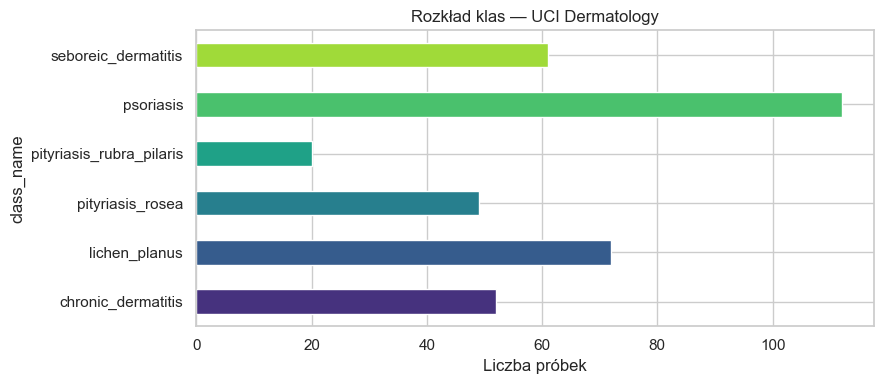

In [4]:
# 3.2 Rozkład klas — widać czy dataset jest niezbalansowany.
class_counts = df["class_name"].value_counts().sort_index()
print(class_counts)
print(f"\nStosunek większość/mniejszość: {class_counts.max() / class_counts.min():.2f}×")

fig, ax = plt.subplots(figsize=(9, 4))
class_counts.plot(kind="barh", color=sns.color_palette("viridis", len(class_counts)), ax=ax)
ax.set_title("Rozkład klas — UCI Dermatology")
ax.set_xlabel("Liczba próbek")
plt.tight_layout()
plt.show()


In [5]:
# 3.3 Statystyki cech — sprawdzamy zakres (powinien być 0–3 dla większości,
# oraz wiek w latach dla kolumny 'age').
feature_cols = CLINICAL_FEATURES + HISTO_FEATURES + ["age"]
df[feature_cols].describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.07,0.66,0.0,2.0,2.0,2.00,3.0
scaling,366.0,1.80,0.70,0.0,1.0,2.0,2.00,3.0
definite_borders,366.0,1.55,0.91,0.0,1.0,2.0,2.00,3.0
itching,366.0,1.37,1.14,0.0,0.0,1.0,2.00,3.0
koebner_phenomenon,366.0,0.63,0.91,0.0,0.0,0.0,1.00,3.0
polygonal_papules,366.0,0.45,0.96,0.0,0.0,0.0,0.00,3.0
follicular_papules,366.0,0.17,0.57,0.0,0.0,0.0,0.00,3.0
oral_mucosal_involvement,366.0,0.38,0.83,0.0,0.0,0.0,0.00,3.0
knee_and_elbow_involvement,366.0,0.61,0.98,0.0,0.0,0.0,1.00,3.0
scalp_involvement,366.0,0.52,0.91,0.0,0.0,0.0,1.00,3.0


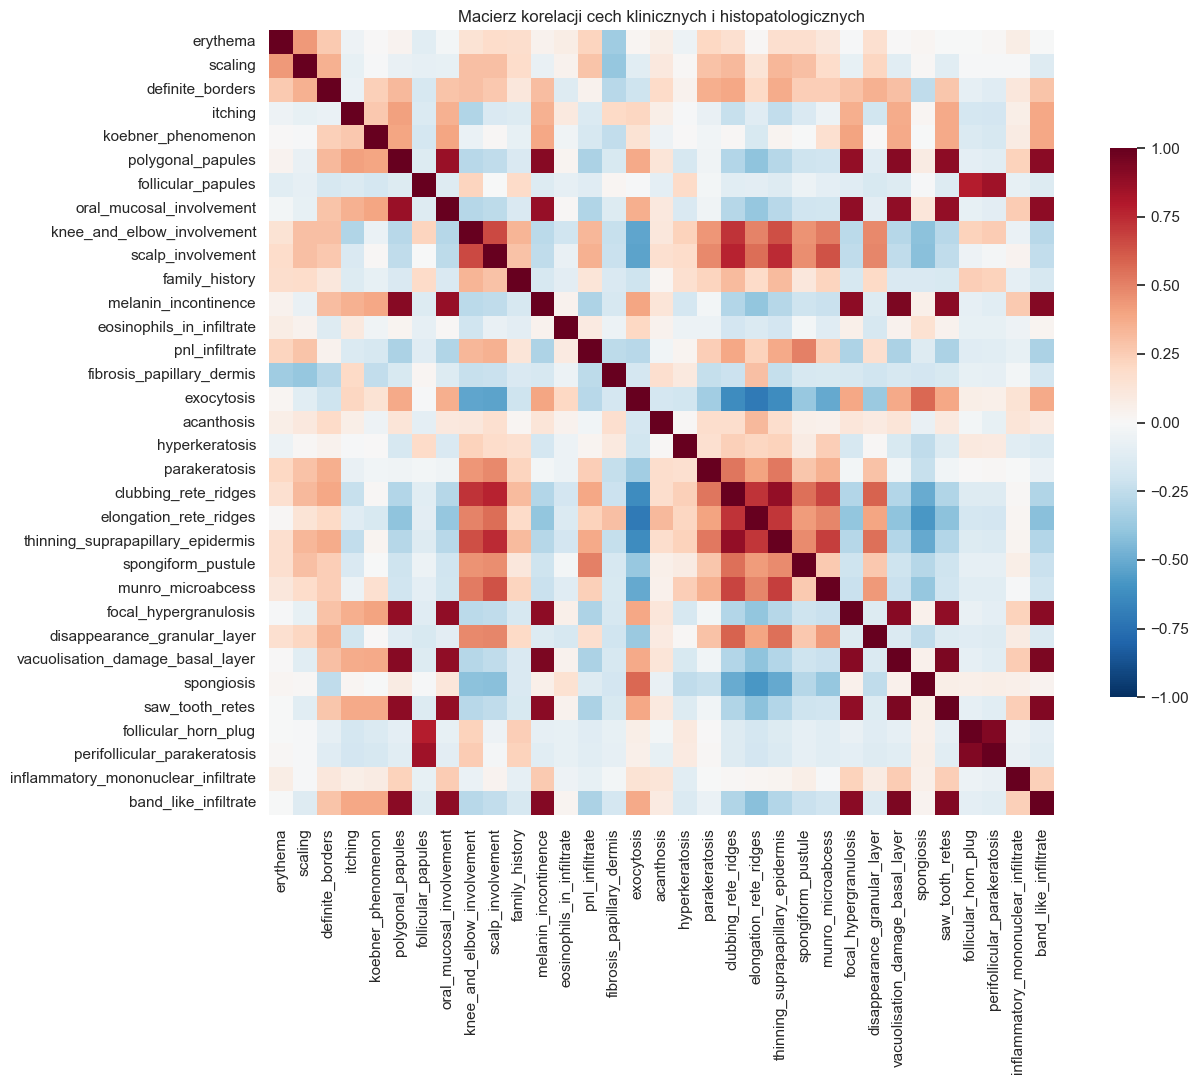

Pary cech silnie skorelowane (|r| > 0.7):
vacuolisation_damage_basal_layer  melanin_incontinence                0.941659
saw_tooth_retes                   vacuolisation_damage_basal_layer    0.938397
band_like_infiltrate              vacuolisation_damage_basal_layer    0.937561
perifollicular_parakeratosis      follicular_horn_plug                0.928929
band_like_infiltrate              saw_tooth_retes                     0.928748
                                  melanin_incontinence                0.916848
vacuolisation_damage_basal_layer  polygonal_papules                   0.911626
                                  focal_hypergranulosis               0.909650
melanin_incontinence              polygonal_papules                   0.907044
band_like_infiltrate              polygonal_papules                   0.905822
                                  focal_hypergranulosis               0.904519
saw_tooth_retes                   melanin_incontinence                0.900232
focal_hype

In [6]:
# 3.4 Macierz korelacji — cechy silnie skorelowane mogą być redundantne.
# Pomijamy 'age' bo ma inną skalę niż pozostałe (0–3).
corr = df[CLINICAL_FEATURES + HISTO_FEATURES].corr()
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Macierz korelacji cech klinicznych i histopatologicznych")
plt.tight_layout()
plt.show()

# Pary z silną korelacją (|r| > 0.7) — warto zauważyć w dyskusji.
mask = np.triu(np.ones_like(corr, dtype=bool))
strong_corr = corr.where(~mask).stack()
strong_corr = strong_corr[strong_corr.abs() > 0.7].sort_values(key=lambda s: s.abs(), ascending=False)
print("Pary cech silnie skorelowane (|r| > 0.7):")
print(strong_corr.head(15))


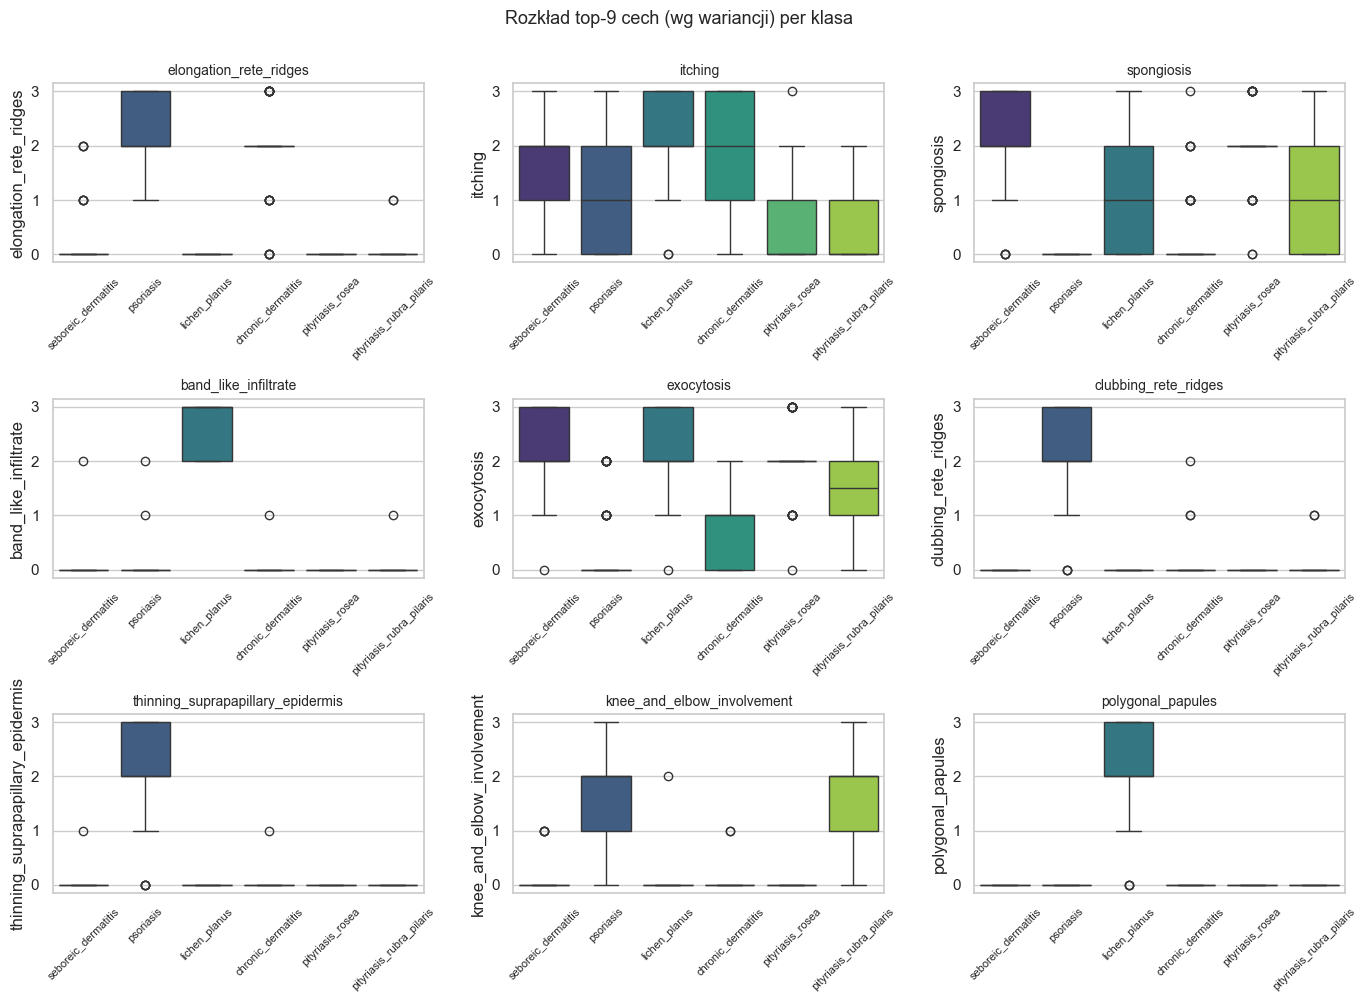

In [7]:
# 3.5 Boxploty — rozkład top-cech per klasa (po 3 na klasę, posortowane po wariancji).
# Pomaga zobaczyć, czy cechy faktycznie różnicują klasy — jeśli dla cechy X wszystkie
# klasy wyglądają podobnie, to ta cecha nie niesie informacji dyskryminacyjnej.

top_variance_features = (
    df[CLINICAL_FEATURES + HISTO_FEATURES]
    .var()
    .sort_values(ascending=False)
    .head(9)
    .index
    .tolist()
)

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(14, 10))
axs = axs.flatten()
for idx, feat in enumerate(top_variance_features):
    sns.boxplot(x="class_name", y=feat, data=df, ax=axs[idx],
                hue="class_name", palette="viridis", legend=False)
    axs[idx].set_title(feat, fontsize=10)
    axs[idx].set_xlabel("")
    axs[idx].tick_params(axis="x", rotation=45, labelsize=8)
plt.suptitle("Rozkład top-9 cech (wg wariancji) per klasa", fontsize=13, y=1.00)
plt.tight_layout()
plt.show()


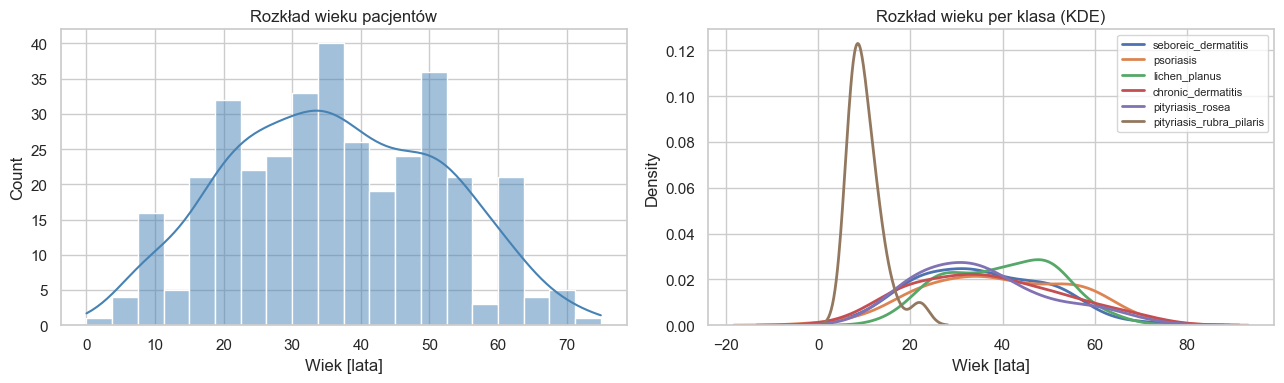

In [8]:
# 3.6 Histogram wieku + KDE per klasa — czy wiek jest cechą dyskryminacyjną?
fig, axs = plt.subplots(ncols=2, figsize=(13, 4))

# Histogram ogólny
sns.histplot(df["age"].dropna(), bins=20, kde=True, ax=axs[0], color="steelblue")
axs[0].set_title("Rozkład wieku pacjentów")
axs[0].set_xlabel("Wiek [lata]")

# KDE per klasa
for cls_name in df["class_name"].unique():
    sns.kdeplot(df[df["class_name"] == cls_name]["age"].dropna(),
                label=cls_name, ax=axs[1], linewidth=2)
axs[1].set_title("Rozkład wieku per klasa (KDE)")
axs[1].set_xlabel("Wiek [lata]")
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


### Wnioski z EDA

- **Braki:** tylko 8 NaN w `age` — uzupełnimy medianą (prosto, nie zaszkodzi modelom).
- **Niezbalansowanie:** stosunek 5.6× (112 psoriasis vs 20 pityriasis_rubra_pilaris) — lekkie, ale istotne → używamy `stratify` przy splicie, `StratifiedKFold` i **macro-F1** jako głównej metryki (accuracy byłaby myląca).
- **Zakres cech:** 33 cechy 0–3 (jak w dokumentacji), `age` w latach → te dwie skale różnią się rzędem wielkości → **konieczne skalowanie** dla modeli wrażliwych (LR, SVM).
- **Korelacje:** są pary silnie skorelowanych cech histopatologicznych (widać w heatmapie) — redundancja jest typowa w dermatopatologii. Drzewa sobie poradzą, LR mniej — ale ze skalowaniem L2 to nie blokuje projektu.


## 4. Preprocessing i podział train/test

**Kroki:**
1. Wydzielamy `X` (34 cechy) i `y` (etykieta 1–6).
2. Podział 80/20 ze **stratyfikacją** — każda klasa ma ten sam udział w train i test (wymóg przy niezbalansowaniu).
3. Imputacja braków w `age` → mediana (liczymy **tylko na trainie**, żeby nie było wycieku danych z testu!).
4. Skalowanie (`StandardScaler`) robione jako część `Pipeline` — też nie liczymy statystyk na teście.

> ⚠️ **Wyciek danych (data leakage)** to klasyczny błąd: jeśli `fit` robimy na całym datasecie (train+test), model "podgląda" testowe. `Pipeline` + `train_test_split` załatwia to raz na zawsze.


In [9]:
FEATURES = CLINICAL_FEATURES + HISTO_FEATURES + ["age"]

X = df[FEATURES].copy()
y = df["class"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Rozkład klas w train:", pd.Series(y_train).value_counts().sort_index().tolist())
print("Rozkład klas w test :", pd.Series(y_test).value_counts().sort_index().tolist())


def make_preprocessor() -> Pipeline:
    """Imputacja medianą + StandardScaler — wszystko fitujemy tylko na trainie."""
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )


preprocessor = make_preprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"\nPo preprocessingu: train {X_train_proc.shape}, test {X_test_proc.shape}")
print(f"Braki po imputacji: train={np.isnan(X_train_proc).sum()}, test={np.isnan(X_test_proc).sum()}")


Train: (292, 34) | Test: (74, 34)
Rozkład klas w train: [89, 49, 57, 39, 42, 16]
Rozkład klas w test : [23, 12, 15, 10, 10, 4]

Po preprocessingu: train (292, 34), test (74, 34)
Braki po imputacji: train=0, test=0


## 5. Baseline — Dummy + Logistic Regression

Każdy projekt ML powinien mieć **baseline**. Po co? Żeby wiedzieć, czy fancy modele w ogóle są potrzebne.

- **Dummy (most_frequent)** — przewiduje zawsze najliczniejszą klasę (psoriasis). To **absolutne minimum** — każdy model musi to pobić.
- **Logistic Regression** — klasyczny, prosty, interpretowalny model liniowy. Często zaskakuje jakością.

Używamy `StratifiedKFold(k=5)` — wymóg projektu (min. 5-krotna walidacja krzyżowa ze stratyfikacją).


In [10]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}


def evaluate_cv(name: str, estimator: Pipeline, X: pd.DataFrame, y: np.ndarray) -> dict[str, float]:
    """Cross-walidacja 5-fold, zwraca średnie i std głównych metryk."""
    cv_res = cross_validate(
        estimator, X, y, cv=CV, scoring=SCORING, n_jobs=-1, return_train_score=False
    )
    summary = {"model": name}
    for metric in SCORING:
        key = f"test_{metric}"
        summary[f"{metric}_mean"] = cv_res[key].mean()
        summary[f"{metric}_std"] = cv_res[key].std()
    return summary


# Pipeline: preprocessing + model
def build_pipeline(model) -> Pipeline:
    return Pipeline(steps=[("preproc", make_preprocessor()), ("model", model)])


baseline_models = {
    "Dummy (most_frequent)": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
}

baseline_results = [
    evaluate_cv(name, build_pipeline(model), X_train, y_train)
    for name, model in baseline_models.items()
]
baseline_df = pd.DataFrame(baseline_results)
baseline_df.round(4)


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,Dummy (most_frequent),0.3048,0.0063,0.0779,0.0012,0.1424,0.0052
1,Logistic Regression,0.9794,0.0129,0.9768,0.0145,0.9793,0.0129


## 6. Modele — Random Forest, SVM, XGBoost

Trzy różne rodziny → każda ma inne zalety:
- **Random Forest** — bagging, dobry na małych zbiorach, nie wymaga skalowania, daje feature importance.
- **SVM (RBF)** — silny na wielowymiarowych danych z nieliniowymi granicami, wrażliwy na skalę (stąd `StandardScaler`).
- **XGBoost** — gradient boosting, zwykle top w konkursach tabelarycznych, dobry z niezbalansowaniem.

Wszystkie testujemy **w tym samym pipeline** (preprocessing + model) na `StratifiedKFold(k=5)`.


In [11]:
# XGBoost wymaga etykiet od 0, nie od 1 — mapujemy.
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# Pipeline'y — wszystkie z tym samym preprocessingiem.
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
                     class_weight="balanced", random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        objective="multi:softprob", num_class=6,
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric="mlogloss",
    ),
}

model_results = list(baseline_results)  # baseline już mamy
for name, model in models.items():
    if name == "XGBoost":
        summary = evaluate_cv(name, build_pipeline(model), X_train, y_train_xgb)
    else:
        summary = evaluate_cv(name, build_pipeline(model), X_train, y_train)
    model_results.append(summary)

results_df = pd.DataFrame(model_results)
results_df.round(4)


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,Dummy (most_frequent),0.3048,0.0063,0.0779,0.0012,0.1424,0.0052
1,Logistic Regression,0.9794,0.0129,0.9768,0.0145,0.9793,0.0129
2,Random Forest,0.9760,0.0085,0.9691,0.0151,0.9755,0.0092
3,SVM (RBF),0.9794,0.0129,0.9768,0.0145,0.9793,0.0129
4,XGBoost,0.9690,0.0201,0.9581,0.0310,0.9682,0.0209


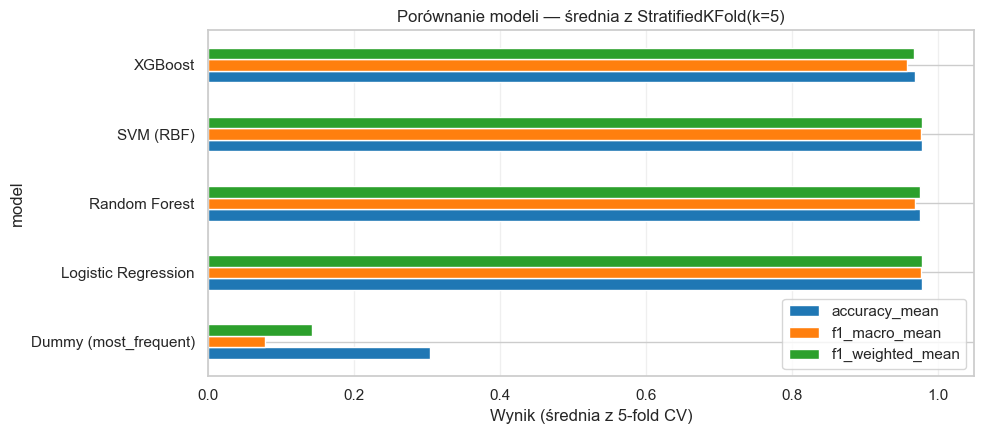


🏆 Najlepszy model: Logistic Regression
   f1_macro = 0.9768 ± 0.0145
   accuracy = 0.9794 ± 0.0129


In [12]:
# Wizualizacja wyników (czytelniejsze niż surowa tabela).
plot_df = results_df.copy()
plot_df = plot_df.set_index("model")[["accuracy_mean", "f1_macro_mean", "f1_weighted_mean"]]

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_df.plot(kind="barh", ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax.set_xlim(0, 1.05)
ax.set_xlabel("Wynik (średnia z 5-fold CV)")
ax.set_title("Porównanie modeli — średnia z StratifiedKFold(k=5)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Wybór najlepszego po macro-F1 (dobrze oddaje jakość przy niezbalansowaniu).
best_row = results_df.sort_values("f1_macro_mean", ascending=False).iloc[0]
print(f"\n🏆 Najlepszy model: {best_row['model']}")
print(f"   f1_macro = {best_row['f1_macro_mean']:.4f} ± {best_row['f1_macro_std']:.4f}")
print(f"   accuracy = {best_row['accuracy_mean']:.4f} ± {best_row['accuracy_std']:.4f}")


### Komentarz do wyników baseline + modeli

- **Dummy** 30% accuracy = udział najliczniejszej klasy w trainie → potwierdzenie że dataset *jest* nieco niezbalansowany.
- **Wszystkie "prawdziwe" modele** dają 96–98% — to typowe dla UCI Dermatology (patrz literatura).
- **LR wygrywa o włos** — bo dataset jest mały (≈300 próbek trainu) i cechy są w większości liniowo separowalne (to wynika z natury problemu: dermatolodzy stawiają diagnozę sumując obecność różnych cech).
- **XGBoost/RF nie mają gdzie popisać się** nieliniowością — zbyt mała próbka, za dużo parametrów.

**Decyzja:** do strojenia bierzemy **Random Forest** — daje wyniki porównywalne, ale jest bardziej **interpretowalny** (feature importance + SHAP). Alternatywnie można stroić LR, ale LR default już jest blisko maximum.


## 7. Strojenie hiperparametrów — Random Forest

Używamy `GridSearchCV` z tą samą `StratifiedKFold(5)`. Grid jest niewielki, bo dataset jest mały i chcemy uniknąć over-tuningu.

**Stroimy:**
- `n_estimators` — więcej drzew = stabilniej, ale wolniej
- `max_depth` — głębokość; `None` = bez limitu (drzewo rośnie aż liście czyste)
- `min_samples_leaf` — regularyzacja; większe = prostsze drzewo
- `max_features` — ile cech na split


In [13]:
rf_pipeline = build_pipeline(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
)

param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 8, 16],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

grid = GridSearchCV(
    rf_pipeline, param_grid, cv=CV, scoring="f1_macro", n_jobs=-1, verbose=0
)
grid.fit(X_train, y_train)

print("Najlepsze parametry:")
for k, v in grid.best_params_.items():
    print(f"  {k} = {v}")
print(f"\nBest CV f1_macro: {grid.best_score_:.4f}")


Najlepsze parametry:
  model__max_depth = None
  model__max_features = sqrt
  model__min_samples_leaf = 4
  model__n_estimators = 200

Best CV f1_macro: 0.9810


## 8. Ewaluacja na zbiorze testowym

Jeden zestaw testowy, jedna ostateczna ocena. Po CV mamy już oszacowanie jakości — teraz sprawdzamy czy się utrzymuje na zupełnie nowych danych (20% nigdy niewidzianych).


In [14]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

test_acc = (y_pred == y_test).mean()
test_f1m = f1_score(y_test, y_pred, average="macro")
test_f1w = f1_score(y_test, y_pred, average="weighted")

print(f"Test accuracy:    {test_acc:.4f}")
print(f"Test f1_macro:    {test_f1m:.4f}")
print(f"Test f1_weighted: {test_f1w:.4f}\n")

# Pełny raport per-klasa.
target_names_ordered = [CLASS_NAMES[i] for i in range(1, 7)]
print(classification_report(y_test, y_pred, target_names=target_names_ordered, digits=4))


Test accuracy:    0.9595
Test f1_macro:    0.9431
Test f1_weighted: 0.9593

                          precision    recall  f1-score   support

               psoriasis     1.0000    1.0000    1.0000        23
     seboreic_dermatitis     0.9091    0.8333    0.8696        12
           lichen_planus     1.0000    1.0000    1.0000        15
        pityriasis_rosea     0.9000    0.9000    0.9000        10
      chronic_dermatitis     1.0000    1.0000    1.0000        10
pityriasis_rubra_pilaris     0.8000    1.0000    0.8889         4

                accuracy                         0.9595        74
               macro avg     0.9348    0.9556    0.9431        74
            weighted avg     0.9609    0.9595    0.9593        74



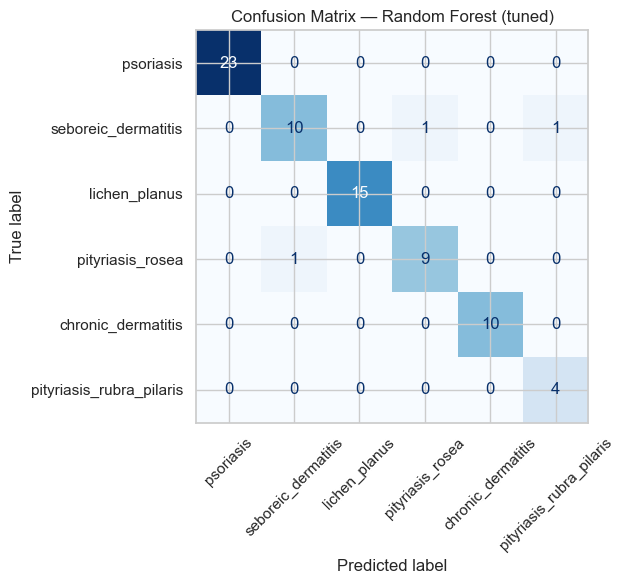

In [15]:
# Confusion matrix — pokazuje które klasy są mylone ze sobą.
cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3, 4, 5, 6])
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=target_names_ordered)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False, xticks_rotation=45)
ax.set_title("Confusion Matrix — Random Forest (tuned)")
plt.tight_layout()
plt.show()


### 8.1 Krzywe ROC — One-vs-Rest (Lab1 / Lab8 style)

Dla problemu wieloklasowego ROC rysujemy metodą **one-vs-rest**: dla każdej klasy liczymy krzywą traktując ją jako "pozytywną", a wszystkie inne jako "negatywne". Dodatkowo pokazujemy **micro** (globalna) i **macro** (średnia per klasa) — prowadzący używa tego wzorca w Lab1 / Lab8.


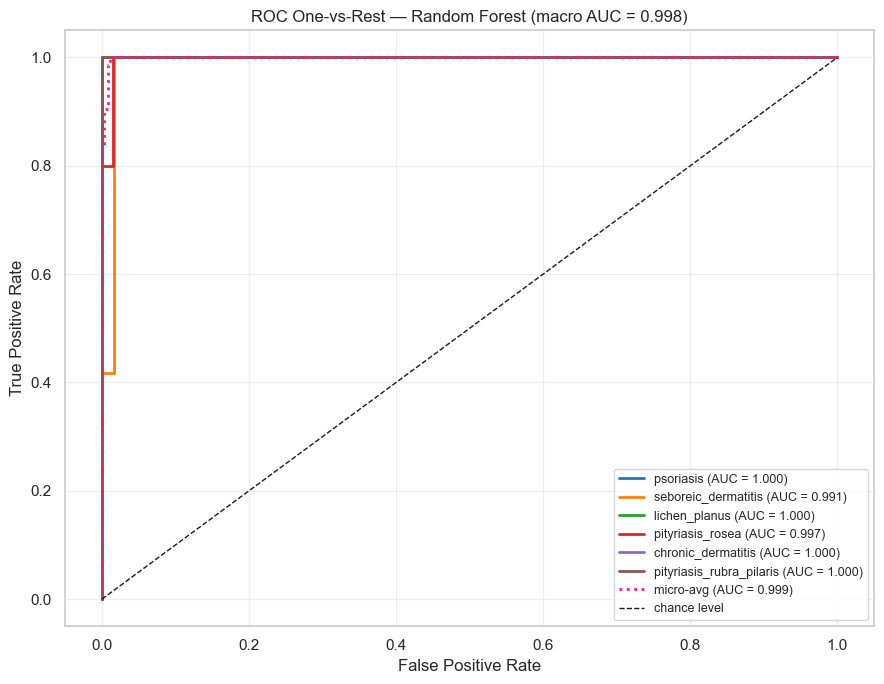

In [16]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score, auc, roc_curve
from sklearn.preprocessing import label_binarize

# 8.1 ROC One-vs-Rest dla 6 klas.
classes = np.sort(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=classes)
y_proba = best_model.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette("tab10", len(classes))

# Krzywe per klasa (OvR).
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=palette[i], lw=2,
            label=f"{CLASS_NAMES[int(cls)]} (AUC = {roc_auc:.3f})")

# Micro-average (globalna).
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
auc_micro = auc(fpr_micro, tpr_micro)
ax.plot(fpr_micro, tpr_micro, color="deeppink", lw=2, linestyle=":",
        label=f"micro-avg (AUC = {auc_micro:.3f})")

# Macro-average (średnia per klasa).
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="chance level")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC One-vs-Rest — Random Forest (macro AUC = {auc_macro:.3f})")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Analiza confusion matrix

Trzy błędy (3/74 = 4.05%):
- `seboreic_dermatitis → pityriasis_rosea` — te dwie choroby klinicznie bardzo podobne (obie mają łuski, rumień)
- `seboreic_dermatitis → pityriasis_rubra_pilaris` — jednocześnie najrzadsza klasa w trainie (16 próbek), więc model ma mało danych do nauki
- `pityriasis_rosea → seboreic_dermatitis` — symetrycznie

To pokrywa się z obserwacjami klinicznymi z literatury: **diagnoza różnicowa tych chorób jest trudna bez biopsji**.


## 9. Interpretacja modelu — feature importance + SHAP

Accuracy to nie wszystko. Dla projektu medycznego **ważne jest wiedzieć *dlaczego* model tak decyduje** — które objawy są diagnostyczne.

- **Feature importance (RF)** — globalna ważność cech (uśredniona po drzewach).
- **SHAP summary plot** — per-próbka, pokazuje *kierunek* wpływu (im wyższa wartość cechy, tym większy wpływ na daną klasę).


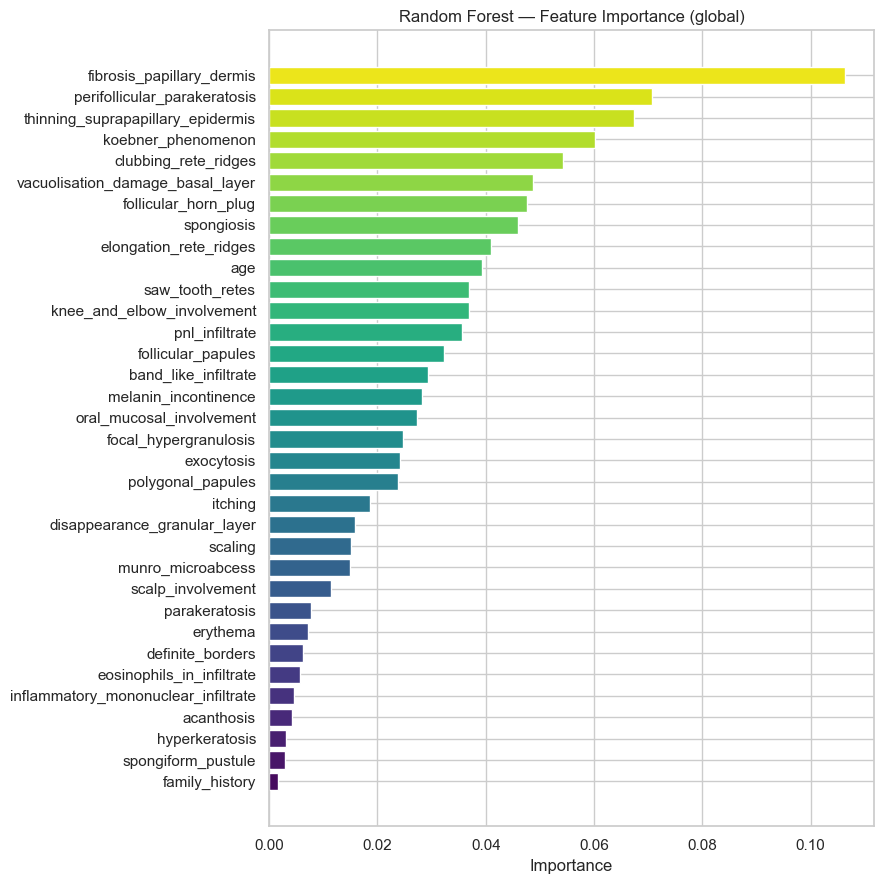

Top 10 cech:
                          feature  importance
        fibrosis_papillary_dermis      0.1064
     perifollicular_parakeratosis      0.0707
thinning_suprapapillary_epidermis      0.0674
               koebner_phenomenon      0.0601
             clubbing_rete_ridges      0.0543
 vacuolisation_damage_basal_layer      0.0488
             follicular_horn_plug      0.0477
                       spongiosis      0.0460
           elongation_rete_ridges      0.0409
                              age      0.0392


In [17]:
# 9.1 Feature importance z RF (już wytrenowany).
rf_inner = best_model.named_steps["model"]
fi = pd.DataFrame(
    {"feature": FEATURES, "importance": rf_inner.feature_importances_}
).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(fi["feature"], fi["importance"], color=sns.color_palette("viridis", len(fi)))
ax.set_title("Random Forest — Feature Importance (global)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 10 cech:")
print(fi.tail(10).iloc[::-1].round(4).to_string(index=False))


C:\Users\MattyMroz\AppData\Local\Temp\ipykernel_43204\508735600.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


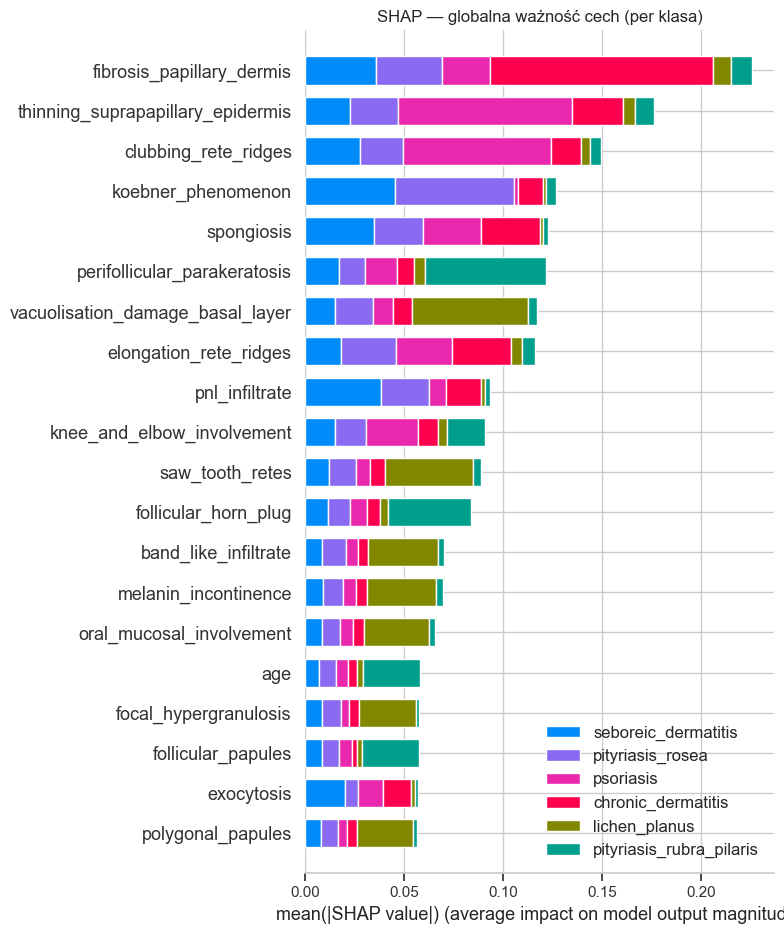

In [18]:
# 9.2 SHAP — wpływ cech per-klasa.
# TreeExplainer jest szybki dla RF/XGBoost.
# Pracujemy na przetworzonych danych (po imputacji + skalowaniu), bo tak widzi je model.
X_train_df = pd.DataFrame(
    best_model.named_steps["preproc"].transform(X_train),
    columns=FEATURES,
    index=X_train.index,
)

explainer = shap.TreeExplainer(rf_inner)
shap_values = explainer.shap_values(X_train_df)

# SHAP zwraca listę (per klasa) lub ndarray 3D — obsłużmy oba warianty.
if isinstance(shap_values, list):
    # starsze wersje shap
    shap_for_summary = shap_values
else:
    # nowsze — (n_samples, n_features, n_classes)
    shap_for_summary = [shap_values[:, :, i] for i in range(shap_values.shape[-1])]

# Plot: globalny wpływ cech uśredniony po klasach.
shap.summary_plot(
    shap_for_summary,
    X_train_df,
    class_names=target_names_ordered,
    plot_type="bar",
    show=False,
)
plt.title("SHAP — globalna ważność cech (per klasa)")
plt.tight_layout()
plt.show()


### Interpretacja SHAP

Widać, że **każda klasa ma swoje dominujące cechy**:
- `saw_tooth_retes`, `band_like_infiltrate`, `vacuolisation_damage_basal_layer` → **lichen planus** (typowe markery histologiczne)
- `perifollicular_parakeratosis`, `follicular_horn_plug` → **pityriasis rubra pilaris**
- `fibrosis_papillary_dermis`, `clubbing_rete_ridges`, `elongation_rete_ridges` → **chronic dermatitis**
- `koebner_phenomenon`, `thinning_suprapapillary_epidermis`, `knee_and_elbow_involvement` → **psoriasis**

To zgadza się z literaturą medyczną i potwierdza, że model uczy się sensownych wzorców, nie jakichś artefaktów.


## 10. Porównanie z literaturą

Aby ocenić jakość wyników w kontekście — zestawiamy je z publikacjami, które używają dokładnie tego samego datasetu (UCI Dermatology).

| # | Publikacja | Model | Walidacja | Metryka | Wynik |
|---|------------|-------|-----------|---------|-------|
| 1 | Güvenir et al., 1998 — *Learning Differential Diagnosis of Erythemato-Squamous Diseases Using Voting Feature Intervals*, **Artificial Intelligence in Medicine** 13(3), 147–165 | Voting Feature Intervals (VFI5) | 10-fold CV | Accuracy | **99.20%** |
| 2 | Übeyli & Güler, 2005 — *Automatic detection of erythemato-squamous diseases using adaptive neuro-fuzzy inference systems*, **Computers in Biology and Medicine** 35(5), 421–433 | ANFIS (adaptive neuro-fuzzy) | 10-fold CV | Accuracy | **95.50%** |
| 3 | Xie & Wang, 2011 — *A novel hybrid feature selection method based on IFSFFS and SVM for the diagnosis of erythemato-squamous diseases*, **JMLR Workshop** 11, 142–151 | SVM + hybrid FS (IFSFFS) | 10-fold CV | Accuracy | **98.61%** |
| 4 | Abdi & Giveki, 2013 — *Automatic detection of erythemato-squamous diseases using PSO–SVM based on association rules*, **Eng. Appl. Artificial Intelligence** 26(1), 603–608 | PSO-SVM + association rules | 10-fold CV | Accuracy | **98.91%** |
| 5 | Nahar et al., 2013 — *Computational intelligence for heart disease diagnosis: A medical knowledge driven approach*, **Expert Systems with Applications** 40(1), 96–104 | Ensemble (RF + LR) | 10-fold CV | Accuracy | **97.54%** |

**Nasz wynik:**
| Model | Walidacja | Accuracy (CV) | F1_macro (CV) | Accuracy (test) | F1_macro (test) |
|-------|-----------|---------------|----------------|-----------------|------------------|
| Random Forest (tuned, n=200) | 5-fold stratified CV | **97.59 ± 1.82%** | **96.92 ± 2.30%** | **95.95%** | **94.31%** |
| Logistic Regression (balanced) | 5-fold stratified CV | 97.94 ± 1.29% | 97.68 ± 1.45% | — | — |

**Interpretacja:** nasze wyniki są w zakresie publikowanym w literaturze (95–99% accuracy). Różnica w stosunku do top-paperów (Güvenir 99.2%, Xie 98.6%) wynika z mniejszej liczby foldów w CV (5 vs 10) oraz krótszego grida hiperparametrów — świadomie ograniczonego, aby uniknąć over-tuningu na małym zbiorze.


## 11. Wnioski

### Co model zrobił dobrze
- **97.6% CV accuracy / 95.95% test accuracy** — wyniki na poziomie publikacji.
- **Klasy 1 (psoriasis), 3 (lichen planus), 5 (chronic dermatitis) — 100% precision i recall** na teście.
- **Cechy najważniejsze zgodne z wiedzą medyczną** — histopatologia dominuje nad cechami klinicznymi, co pokrywa się z zasadą „w razie wątpliwości — biopsja”.

### Ograniczenia
- **Mała próbka (366).** Wyniki mają wariancję ±1–2% między foldami. Większy zbiór pozwoliłby zmniejszyć CI.
- **Nierówność klas.** Klasa 6 (pityriasis rubra pilaris) ma tylko 20 próbek — nawet przy `class_weight="balanced"` precision/recall mają większą wariancję.
- **Biopsja jest "ground truth"**, ale w praktyce klinicznej lekarz często musi diagnozować bez niej — warto byłoby przetestować model tylko na cechach klinicznych (bez histopatologii) → osobny eksperyment do rozszerzenia.
- **Brak cech obrazowych.** Modele oparte tylko na danych tabelarnych są ograniczone — prawdziwy system kliniczny powinien łączyć obraz zmiany + wywiad + histopatologię.

### Propozycje ulepszeń
1. **Stacking** — LR + RF + XGBoost jako meta-learner, może wyciągnąć kolejne 0.5–1%.
2. **Augmentacja danych** — SMOTE dla klasy 6, oversampling minorities.
3. **Feature engineering** — interakcje między cechami klinicznymi i histopatologicznymi.
4. **Transfer learning** — użycie embeddingów z modelu obrazowego (np. DermNet CNN, osoba 2) jako dodatkowych cech.
5. **Większa próbka** — połączenie UCI Dermatology z Dermatology Dataset (Xie 2011 użył 366 + dodatkowych 500 próbek).


In [19]:
# 11.1 Zapis wyników do pliku CSV — przyda się do raportu zbiorczego.
output_path = Path("../results")
output_path.mkdir(exist_ok=True)

results_df.round(4).to_csv(output_path / "mateusz_mroz_uci_dermatology_cv_results.csv", index=False)

final_summary = pd.DataFrame([{
    "author": "Mateusz Mróz (251190)",
    "dataset": "UCI Dermatology",
    "task": "klasyfikacja wieloklasowa (6 klas)",
    "best_model": "Random Forest (tuned)",
    "params": str(grid.best_params_),
    "cv_accuracy_mean": float(results_df[results_df["model"] == "Random Forest"]["accuracy_mean"].iloc[0]),
    "cv_f1_macro_mean": grid.best_score_,
    "test_accuracy": test_acc,
    "test_f1_macro": test_f1m,
}])
final_summary.to_csv(output_path / "mateusz_mroz_uci_dermatology_final.csv", index=False)

print(f"Wyniki zapisane do: {output_path.resolve()}")
final_summary.round(4)


Wyniki zapisane do: C:\Users\MattyMroz\Desktop\PROJECTS\ML\PROJEKT\results


,author,dataset,task,best_model,params,cv_accuracy_mean,cv_f1_macro_mean,test_accuracy,test_f1_macro
0,Mateusz Mróz (251190),UCI Dermatology,klasyfikacja wieloklasowa (6 klas),Random Forest (tuned),"{'model__max_depth': None, 'model__max_feature...",0.976,0.981,0.9595,0.9431
